In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("insights-data.csv")
df.head()

,Age,Weight_kg,Height_ft,Marital_Status,PCOS,Family_History_PCOS,Menstrual_Irregularity,Hormonal_Imbalance,Hyperandrogenism,Hirsutism,...,Diet_Multivitamin,Vegetarian,Exercise_Frequency,Exercise_Type,Exercise_Duration,Sleep_Hours,Stress_Level,Smoking,Exercise_Benefit,PCOS_Medication
0,20-25,66.0,157.48,Unmarried,No,No,Yes,No,No,No,...,0,No,Rarely,"Cardio (e.g., running, cycling, swimming)",30 minutes,Less than 6 hours,No,No,Somewhat,No.
1,Less than 20,56.0,165.10,Unmarried,No,No,No,No,No,No,...,0,No,Daily,No Exercise,Less than 30 minutes,6-8 hours,No,No,Somewhat,No.
2,Less than 20,89.0,167.64,Unmarried,No,Yes,No,No,No,Yes,...,0,No,Rarely,"Cardio (e.g., running, cycling, swimming)",Less than 30 minutes,6-8 hours,Yes,No,Somewhat,No.
3,20-25,55.0,160.02,Unmarried,No,Yes,No,Yes,No,Yes,...,1,No,Never,No Exercise,Not Applicable,6-8 hours,Yes,No,Somewhat,No.
4,Less than 20,55.0,160.02,Unmarried,No,No,No,No,No,No,...,0,No,Daily,"Cardio (e.g., running, cycling, swimming)",30 minutes to 1 hour,6-8 hours,Yes,No,Not at All,No.


In [3]:
df.columns

Index(['Age', 'Weight_kg', 'Height_ft', 'Marital_Status', 'PCOS',
       'Family_History_PCOS', 'Menstrual_Irregularity', 'Hormonal_Imbalance',
       'Hyperandrogenism', 'Hirsutism', 'Mental_Health',
       'Conception_Difficulty', 'Insulin_Resistance', 'Diabetes',
       'Childhood_Trauma', 'Cardiovascular_Disease', 'Diet_Bread_Cereals',
       'Diet_Milk_Products', 'Diet_Fruits', 'Diet_Vegetables',
       'Diet_Starchy_Vegetables', 'Diet_NonStarchy_Vegetables', 'Diet_Fats',
       'Diet_Sweets', 'Diet_Fried_Food', 'Diet_Tea_Coffee',
       'Diet_Multivitamin', 'Vegetarian', 'Exercise_Frequency',
       'Exercise_Type', 'Exercise_Duration', 'Sleep_Hours', 'Stress_Level',
       'Smoking', 'Exercise_Benefit', 'PCOS_Medication'],
      dtype='object')

In [4]:
horizon = 7
models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7)
]

In [5]:
data = pd.read_csv("synthetic_data.csv")
data.head()

,Cycle_Length,Age_Range,Irregular_Periods,Weight_Gain,Hair_Loss,Skin_Darkening,Pimples,Fast_Food_Intake,Hair_Growth_Chin,Hair_Growth_Cheeks,...,Hair_Growth_Legs,Hair_Growth_Back,Acne,Dark_Patches,Hair_Thinning,Skin_Tags,Mood_Swings,Fatigue_Level,Exercise_Days_Per_Week,PCOS_Diagnosis
0,3,1,0,0,1,0,1,1,1,1,...,1,1,0,0,1,1,4,2,2,0
1,4,6,1,0,1,0,1,0,0,0,...,1,2,1,0,0,0,1,1,1,1
2,2,6,0,1,0,0,1,2,1,2,...,1,0,0,1,0,1,0,6,0,0
3,4,5,1,0,0,0,0,2,2,0,...,1,1,0,0,0,1,2,5,0,0
4,4,1,1,1,0,0,0,1,2,2,...,1,2,1,0,0,1,2,0,7,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Cycle_Length            267 non-null    int64
 1   Age_Range               267 non-null    int64
 2   Irregular_Periods       267 non-null    int64
 3   Weight_Gain             267 non-null    int64
 4   Hair_Loss               267 non-null    int64
 5   Skin_Darkening          267 non-null    int64
 6   Pimples                 267 non-null    int64
 7   Fast_Food_Intake        267 non-null    int64
 8   Hair_Growth_Chin        267 non-null    int64
 9   Hair_Growth_Cheeks      267 non-null    int64
 10  Hair_Growth_Upper_Lips  267 non-null    int64
 11  Hair_Growth_Arms        267 non-null    int64
 12  Hair_Growth_Legs        267 non-null    int64
 13  Hair_Growth_Back        267 non-null    int64
 14  Acne                    267 non-null    int64
 15  Dark_Patches           

In [7]:

def pcos_eda_visualization(df):
    """
    Performs EDA visualization for:
    1. Cycle vs Diet
    2. Cycle vs Exercise
    3. Diet vs Symptom categories
    4. Symptom categories vs Exercise
    """

    # -------------------------
    # 1️⃣ Create Symptom Groups
    # -------------------------
    
    hirsutism_cols = [
        'Hair_Growth_Chin', 'Hair_Growth_Cheeks',
        'Hair_Growth_Upper_Lips', 'Hair_Growth_Arms',
        'Hair_Growth_Legs', 'Hair_Growth_Back'
    ]
    
    hairfall_cols = ['Hair_Loss', 'Hair_Thinning']
    acne_cols = ['Acne', 'Pimples']
    
    # Create aggregated symptom scores
    df['Hirsutism_Score'] = df[hirsutism_cols].mean(axis=1)
    df['Hairfall_Score'] = df[hairfall_cols].mean(axis=1)
    df['Acne_Score'] = df[acne_cols].mean(axis=1)
    df['Mood_Score'] = df['Mood_Swings']
    df['Fatigue_Score'] = df['Fatigue_Level']
    
    # -------------------------
    # 2️⃣ Selected Variables
    # -------------------------
    
    analysis_cols = [
        'Cycle_Length',
        'Fast_Food_Intake',
        'Exercise_Days_Per_Week',
        'Hirsutism_Score',
        'Hairfall_Score',
        'Acne_Score',
        'Mood_Score',
        'Fatigue_Score'
    ]
    
    sub_df = df[analysis_cols]

    # -------------------------
    # 3️⃣ Correlation Matrix
    # -------------------------
    
    plt.figure(figsize=(10, 8))
    corr = sub_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix - Cycle, Diet, Exercise & Symptoms")
    plt.show()

    # -------------------------
    # 4️⃣ Pairwise Visualizations
    # -------------------------

    # Cycle vs Diet
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Cycle_Length', y='Fast_Food_Intake', data=df)
    plt.title("Cycle Length vs Fast Food Intake")
    plt.show()

    # Cycle vs Exercise
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Cycle_Length', y='Exercise_Days_Per_Week', data=df)
    plt.title("Cycle Length vs Exercise Days")
    plt.show()

    # Diet vs Symptoms
    symptom_scores = ['Hirsutism_Score','Hairfall_Score','Acne_Score','Mood_Score','Fatigue_Score']
    
    for symptom in symptom_scores:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x='Fast_Food_Intake', y=symptom, data=df)
        plt.title(f"Fast Food Intake vs {symptom}")
        plt.show()

    # Symptoms vs Exercise
    for symptom in symptom_scores:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x='Exercise_Days_Per_Week', y=symptom, data=df)
        plt.title(f"Exercise vs {symptom}")
        plt.show()

    print("EDA Visualization Completed Successfully.")

In [8]:
pcos_df = data[data['PCOS_Diagnosis']==1]

In [9]:
normal_df = data[data['PCOS_Diagnosis']==0]

In [10]:
normal_df.describe()
pcos_df.describe()

,Cycle_Length,Age_Range,Irregular_Periods,Weight_Gain,Hair_Loss,Skin_Darkening,Pimples,Fast_Food_Intake,Hair_Growth_Chin,Hair_Growth_Cheeks,...,Hair_Growth_Legs,Hair_Growth_Back,Acne,Dark_Patches,Hair_Thinning,Skin_Tags,Mood_Swings,Fatigue_Level,Exercise_Days_Per_Week,PCOS_Diagnosis
count,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,...,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.0
mean,2.975610,2.723577,0.715447,0.715447,0.723577,0.528455,0.463415,1.016260,1.024390,0.845528,...,0.959350,1.024390,0.674797,0.487805,0.463415,0.512195,3.609756,3.634146,3.130081,1.0
std,1.560073,1.964024,0.453047,0.453047,0.449058,0.501231,0.500699,0.829613,0.824456,0.830095,...,0.813799,0.863309,0.470367,0.501896,0.500699,0.501896,2.227379,2.406509,2.357268,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.500000,1.000000,1.0
50%,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,4.000000,4.000000,3.000000,1.0
75%,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,6.000000,6.000000,5.000000,1.0
max,5.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,7.000000,7.000000,7.000000,1.0


In [11]:
def pcos_visual_insights(df):

    # -----------------------------
    # Symptom Grouping
    # -----------------------------
    hirsutism_cols = [
        'Hair_Growth_Chin','Hair_Growth_Cheeks',
        'Hair_Growth_Upper_Lips','Hair_Growth_Arms',
        'Hair_Growth_Legs','Hair_Growth_Back'
    ]

    hairfall_cols = ['Hair_Loss','Hair_Thinning']
    acne_cols = ['Acne','Pimples']

    df['Hirsutism_Score'] = df[hirsutism_cols].mean(axis=1)
    df['Hairfall_Score'] = df[hairfall_cols].mean(axis=1)
    df['Acne_Score'] = df[acne_cols].mean(axis=1)

    df['Mood_Score'] = df['Mood_Swings']
    df['Fatigue_Score'] = df['Fatigue_Level']

    features = [
        'Cycle_Length',
        'Fast_Food_Intake',
        'Exercise_Days_Per_Week',
        'Hirsutism_Score',
        'Hairfall_Score',
        'Acne_Score',
        'Mood_Score',
        'Fatigue_Score'
    ]

    # ----------------------------------
    # 1️⃣ Correlation Heatmap
    # ----------------------------------
    plt.figure(figsize=(8,6))
    sns.heatmap(df[features].corr(method='spearman'),
                annot=True,
                cmap='coolwarm')

    plt.title("Spearman Correlation Between Lifestyle & Symptoms")
    plt.show()

    # ----------------------------------
    # 2️⃣ Lifestyle vs Symptoms
    # ----------------------------------
    symptoms = [
        'Hirsutism_Score',
        'Hairfall_Score',
        'Acne_Score',
        'Mood_Score',
        'Fatigue_Score'
    ]

    for s in symptoms:
        plt.figure()
        sns.regplot(x='Exercise_Days_Per_Week', y=s, data=df)
        plt.title(f"Exercise vs {s}")
        plt.show()

    for s in symptoms:
        plt.figure()
        sns.regplot(x='Fast_Food_Intake', y=s, data=df)
        plt.title(f"Diet vs {s}")
        plt.show()

    # ----------------------------------
    # 3️⃣ Mutual Information Importance
    # ----------------------------------
    X = df[features]
    y = df['PCOS_Diagnosis']

    mi = mutual_info_classif(X, y)

    mi_scores = pd.Series(mi, index=features)

    plt.figure(figsize=(7,5))
    mi_scores.sort_values().plot(kind='barh')
    plt.title("Feature Importance (Mutual Information)")
    plt.xlabel("Information Gain")
    plt.show()

    # ----------------------------------
    # 4️⃣ Random Forest Feature Importance
    # ----------------------------------
    model = RandomForestClassifier(n_estimators=200)
    model.fit(X, y)

    importance = pd.Series(model.feature_importances_, index=features)

    plt.figure(figsize=(7,5))
    importance.sort_values().plot(kind='barh')
    plt.title("Feature Importance (Random Forest)")
    plt.xlabel("Importance Score")
    plt.show()

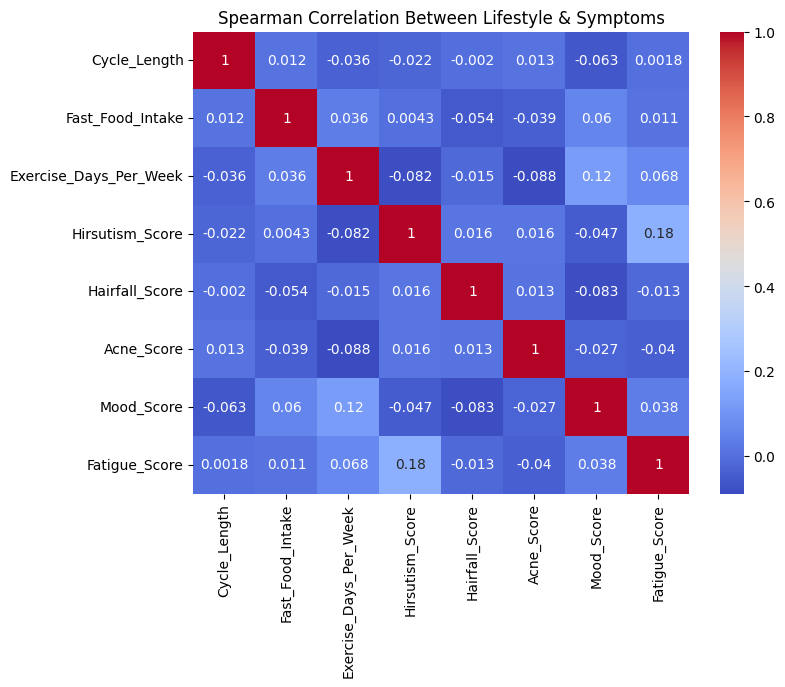

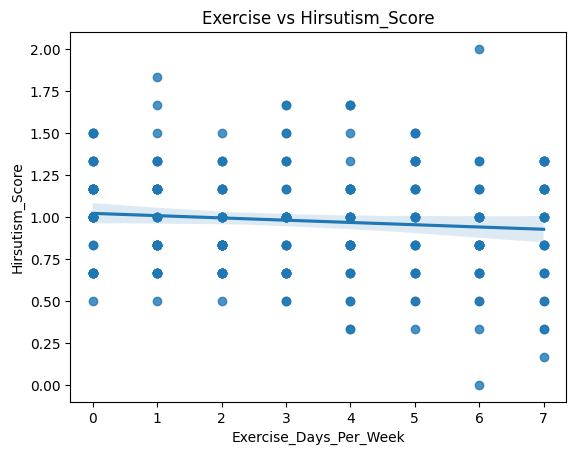

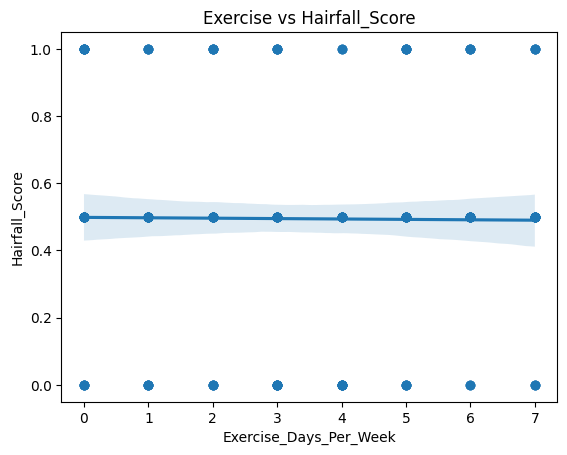

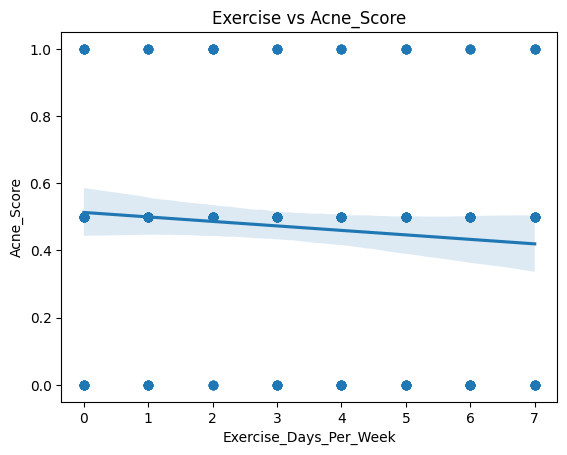

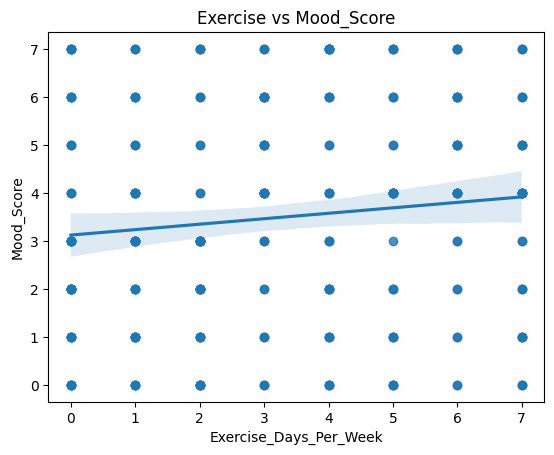

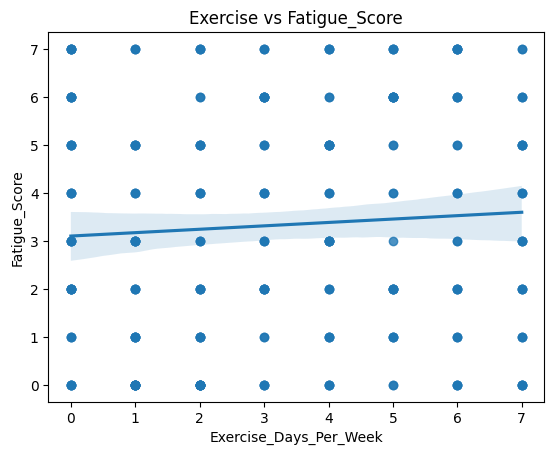

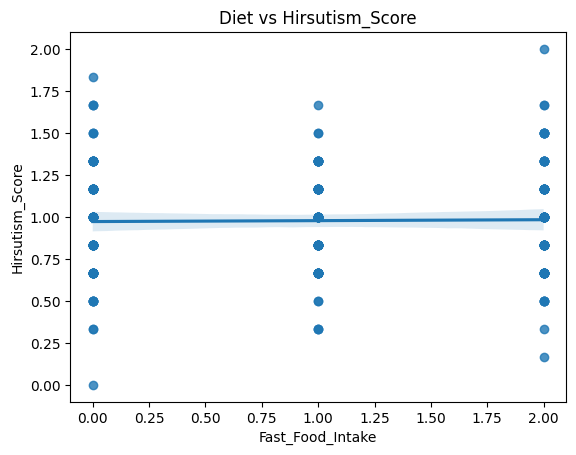

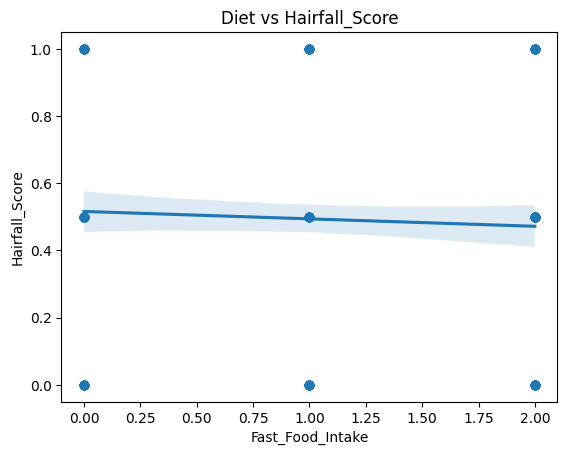

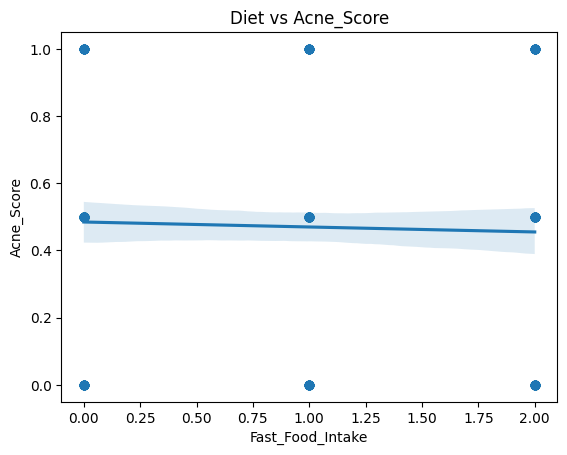

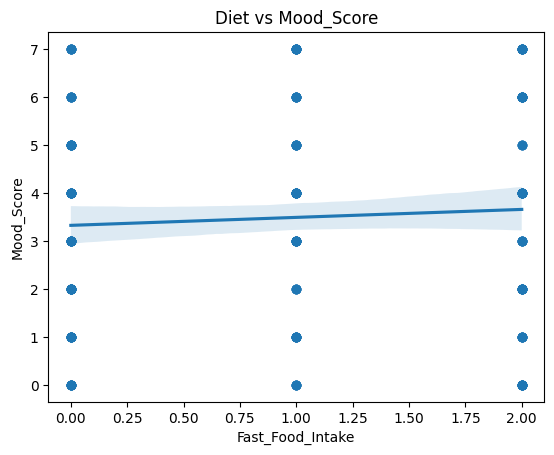

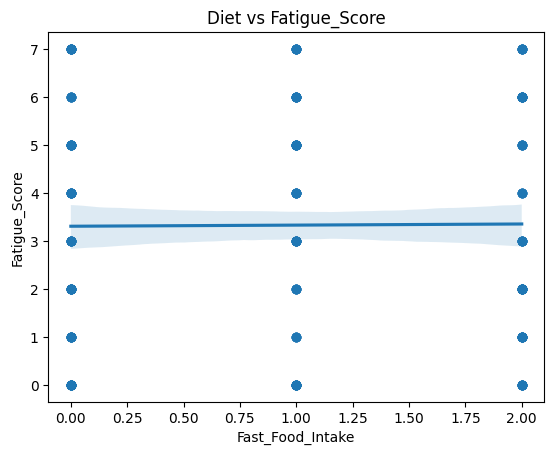

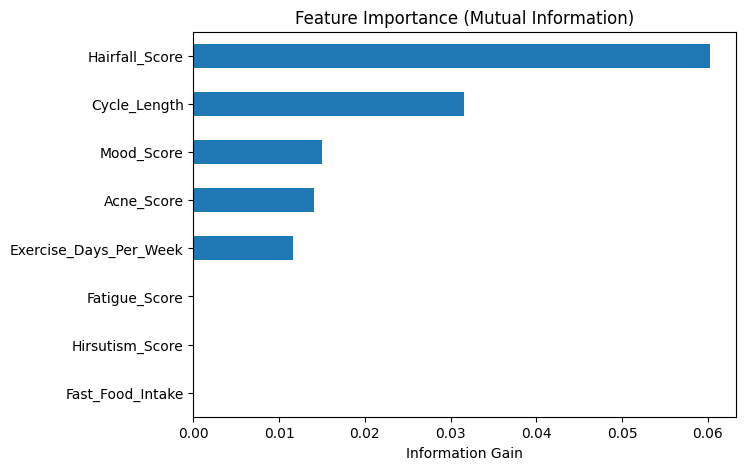

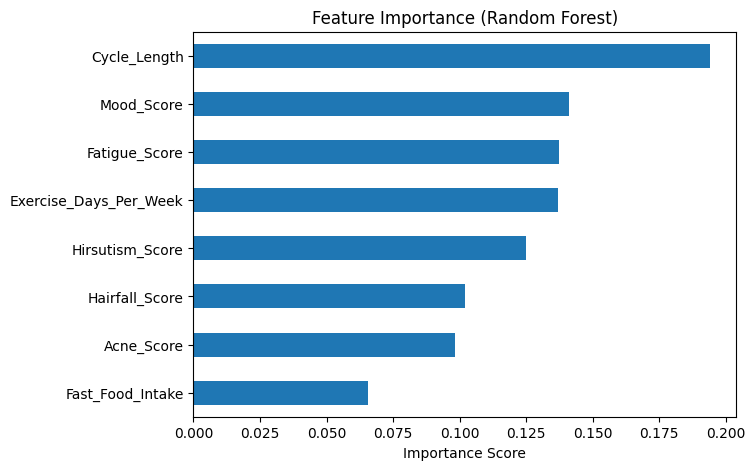

In [17]:
pcos_visual_insights(data)

In [12]:
pcos_df.head()

,Cycle_Length,Age_Range,Irregular_Periods,Weight_Gain,Hair_Loss,Skin_Darkening,Pimples,Fast_Food_Intake,Hair_Growth_Chin,Hair_Growth_Cheeks,...,Hair_Growth_Legs,Hair_Growth_Back,Acne,Dark_Patches,Hair_Thinning,Skin_Tags,Mood_Swings,Fatigue_Level,Exercise_Days_Per_Week,PCOS_Diagnosis
1,4,6,1,0,1,0,1,0,0,0,...,1,2,1,0,0,0,1,1,1,1
4,4,1,1,1,0,0,0,1,2,2,...,1,2,1,0,0,1,2,0,7,1
7,2,3,1,1,0,0,0,1,0,2,...,1,2,1,1,1,1,1,7,0,1
9,4,0,1,1,1,0,0,1,1,1,...,1,2,0,1,0,1,6,5,3,1
11,2,3,1,0,1,1,0,0,0,1,...,0,2,1,1,1,0,4,0,3,1
